<a href="https://colab.research.google.com/github/134ashwani/Deep-Fake-Face-Swapped-Detection/blob/main/DeepFake_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: Importing Required Libraries**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, LSTM, TimeDistributed
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import shuffle
import matplotlib.pyplot as plt
import seaborn as sns

**Step 2: Define Parameters and Video Paths**

In [ ]:
SEQUENCE_LENGTH = 10
FRAME_SIZE = (224, 224)
OUTPUT_FOLDER = '/content/frames'

video_paths_real = ["/content/v1.mp4", "/content/v2.mp4"]
video_paths_fake = ["/content/vs1.mp4", "/content/vs2.mp4"]
video_paths = video_paths_real + video_paths_fake

for path in video_paths:
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    else:
        print(f"[✓] Found: {path}")


[✓] Found: /content/v1.mp4
[✓] Found: /content/v2.mp4
[✓] Found: /content/vs1.mp4
[✓] Found: /content/vs2.mp4


**Step 3: Extract Frames from Videos**

In [ ]:
def extract_frames(video_path, output_folder):
    cap = cv2.VideoCapture(video_path)
    frame_count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_path = os.path.join(output_folder, f"{frame_count}.jpg")
        cv2.imwrite(frame_path, frame)
        frame_count += 1
    cap.release()


**Step 4: Preprocess Frames**

In [ ]:
def preprocess_frames(frame_path):
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    img = cv2.imread(frame_path)
    if img is None:
        return []
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 4)

    if len(faces) == 0:
        resized = cv2.resize(img, FRAME_SIZE) / 255.0
        return [resized]

    cropped_faces = []
    for (x, y, w, h) in faces:
        face = img[y:y+h, x:x+w]
        face = cv2.resize(face, FRAME_SIZE) / 255.0
        cropped_faces.append(face)
    return cropped_faces


**Step 5: Load Dataset (Frames + Labels)**

In [ ]:
def load_dataset(video_paths, output_folder):
    frames = []
    labels = []
    for video_path in video_paths:
        video_name = os.path.splitext(os.path.basename(video_path))[0]
        video_output_folder = os.path.join(output_folder, video_name)
        os.makedirs(video_output_folder, exist_ok=True)
        extract_frames(video_path, video_output_folder)

        frame_files = sorted([f for f in os.listdir(video_output_folder) if f.endswith('.jpg')])
        for f in frame_files:
            full_path = os.path.join(video_output_folder, f)
            faces = preprocess_frames(full_path)
            for face in faces:
                frames.append(face)
                label = 0 if "v1" in video_path or "v2" in video_path else 1
                labels.append(label)
    return np.array(frames), np.array(labels)


**Step 6: Create Sequences**

In [ ]:
def create_sequences(frames, labels, sequence_length):
    sequences, sequence_labels = [], []
    for i in range(0, len(frames) - sequence_length, sequence_length):
        sequences.append(frames[i:i + sequence_length])
        sequence_labels.append(labels[i + sequence_length // 2])
    return np.array(sequences), np.array(sequence_labels)


**Step 7: Prepare Training and Validation Data**

In [ ]:
frames, labels = load_dataset(video_paths, OUTPUT_FOLDER)
print(f"Total frames: {len(frames)}, Labels: {len(labels)}")

frames, labels = shuffle(frames, labels, random_state=42)
train_frames, val_frames, train_labels, val_labels = train_test_split(frames, labels, test_size=0.2, random_state=42)
train_seq, train_seq_labels = create_sequences(train_frames, train_labels, SEQUENCE_LENGTH)
val_seq, val_seq_labels = create_sequences(val_frames, val_labels, SEQUENCE_LENGTH)

print(f"Train shape: {train_seq.shape}, Validation shape: {val_seq.shape}")


Total frames: 401, Labels: 401
Train shape: (31, 10, 224, 224, 3), Validation shape: (8, 10, 224, 224, 3)


**Step 8: Build CNN-LSTM Model**

In [ ]:
model = Sequential([
    TimeDistributed(Conv2D(32, (3, 3), activation='relu'), input_shape=(SEQUENCE_LENGTH, 224, 224, 3)),
    TimeDistributed(MaxPooling2D((2, 2))),
    TimeDistributed(Conv2D(64, (3, 3), activation='relu')),
    TimeDistributed(MaxPooling2D((2, 2))),
    TimeDistributed(Flatten()),
    LSTM(64),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Step 9: Train the Model**

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', save_best_only=True)
]

history = model.fit(train_seq, train_seq_labels,
                    validation_data=(val_seq, val_seq_labels),
                    epochs=20,
                    batch_size=8,
                    callbacks=callbacks)


Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.4041 - loss: 0.7027 

4/4 ━━━━━━━━━━━━━━━━━━━━ 100s 23s/step - accuracy: 0.4007 - loss: 0.7037 - val_accuracy: 0.2500 - val_loss: 0.7212
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.5926 - loss: 0.6858 

4/4 ━━━━━━━━━━━━━━━━━━━━ 141s 24s/step - accuracy: 0.5773 - loss: 0.6874 - val_accuracy: 0.2500 - val_loss: 0.7102
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.4694 - loss: 0.6942 

4/4 ━━━━━━━━━━━━━━━━━━━━ 104s 26s/step - accuracy: 0.4594 - loss: 0.6945 - val_accuracy: 0.7500 - val_loss: 0.6805
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21s/step - accuracy: 0.5376 - loss: 0.6924 

4/4 ━━━━━━━━━━━━━━━━━━━━ 95s 25s/step - accuracy: 0.5269 - loss: 0.6931 - val_accuracy: 0.7500 - val_loss: 0.6795
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 133s 22s/step - accuracy: 0.4898 - loss: 0.6963 - val_accuracy: 0.2500 - val_loss: 0.7072
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 140s 21s/step - accuracy: 0.4356 - loss: 0.6979 - val_accuracy: 0.2500 - val_loss: 0.7081
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 86s 22s/step - accuracy: 0.5356 - loss: 0.6937 - val_accuracy: 0.2500 - val_loss: 0.7270
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 147s 22s/step - accuracy: 0.5065 - loss: 0.6945 - val_accuracy: 0.2500 - val_loss: 0.7318
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 137s 22s/step - accuracy: 0.5190 - loss: 0.6933 - val_accuracy: 0.2500 - val_loss: 0.7299


**Step 10: Plot Accuracy and Loss Graph**

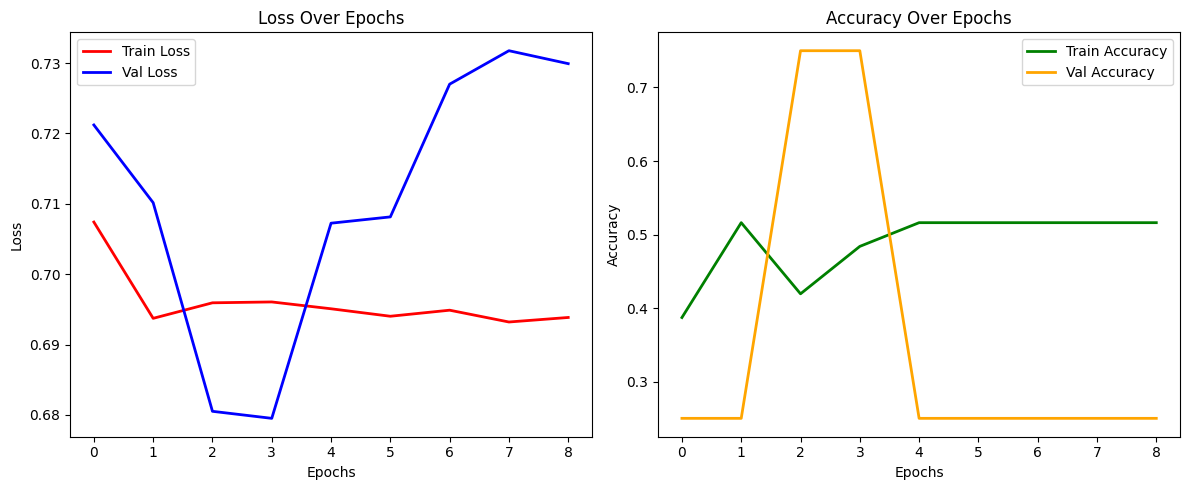

In [ ]:
def plot_history(history):
    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss', color='red', linewidth=2)
    plt.plot(history.history['val_loss'], label='Val Loss', color='blue', linewidth=2)
    plt.title("Loss Over Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy', color='green', linewidth=2)
    plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange', linewidth=2)
    plt.title("Accuracy Over Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)


**Step 11: Evaluate the Model**

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

🎯 Accuracy: 0.75

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.75      1.00      0.86         6
           1       0.00      0.00      0.00         2

    accuracy                           0.75         8
   macro avg       0.38      0.50      0.43         8
weighted avg       0.56      0.75      0.64         8



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


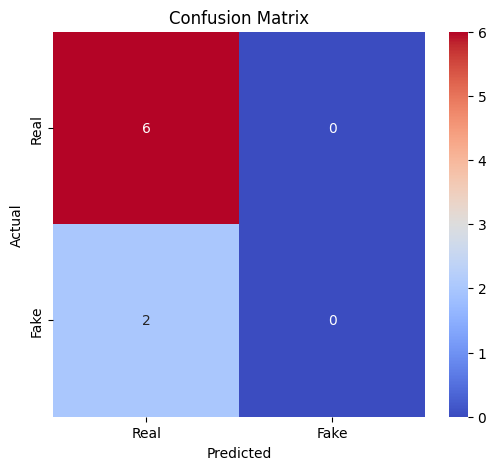

In [ ]:
preds = model.predict(val_seq)
preds_class = np.round(preds).flatten()
acc = accuracy_score(val_seq_labels, preds_class)

print(f"\n🎯 Accuracy: {acc:.2f}")
print("\n📋 Classification Report:\n", classification_report(val_seq_labels, preds_class))


def plot_confusion_matrix(true_labels, pred_labels):
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion_matrix(val_seq_labels, preds_class)


**Step 12: Show Sample Predictions**

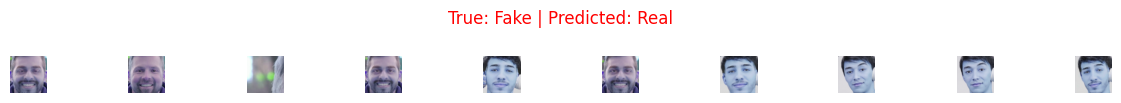

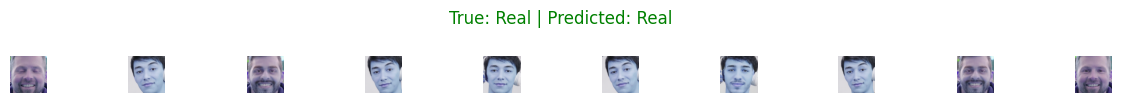

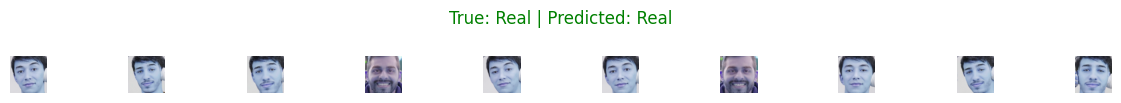

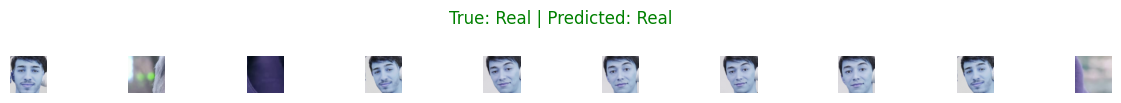

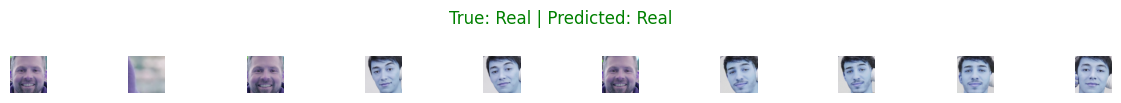

In [ ]:
def show_sample_predictions(sequences, labels, preds, num_samples=5):
    idxs = np.random.choice(len(sequences), num_samples, replace=False)
    for i, idx in enumerate(idxs):
        seq = sequences[idx]
        label = labels[idx]
        pred = int(preds[idx])

        plt.figure(figsize=(12, 1))
        for j in range(len(seq)):
            plt.subplot(1, len(seq), j+1)
            plt.imshow(seq[j])
            plt.axis('off')
        plt.suptitle(f"True: {'Real' if label==0 else 'Fake'} | Predicted: {'Real' if pred==0 else 'Fake'}",
                     fontsize=12, color='green' if label==pred else 'red')
        plt.tight_layout()
        plt.show()

show_sample_predictions(val_seq, val_seq_labels, preds_class)
